<a href="https://colab.research.google.com/github/songwoojin04/machine2/blob/main/11week/WISDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [117]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/11주차/data/WISDM.csv',
    header=None,
    names=['idx', 'user', 'activity', 'timestamp', 'x', 'y', 'z']
)

In [118]:
df

,idx,user,activity,timestamp,x,y,z
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [119]:
df = df[df['activity'] == 'Jogging']

In [120]:
X = df[['x', 'y', 'z']].apply(pd.to_numeric, errors='coerce')
X = X.dropna()

In [121]:
max_rows = 60000
if len(X) > max_rows:
    X = X.sample(max_rows, random_state=42)

In [122]:
X_train, X_test = train_test_split(
    X.values,
    test_size=0.2,
    random_state=42
)

In [123]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [128]:
input_dim = X_train.shape[1]
encoding_dim = 6

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)
encoded = Dense(3, activation='relu')(encoded)
decoded = Dense(3, activation='relu')(encoded)
# 2) 출력은 linear
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
# 3) learning rate 줄이기
autoencoder.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

In [129]:
history = autoencoder.fit(
		X_train,
		X_train,
		epochs=50,
		batch_size=256,
		shuffle=True,
		validation_split=0.1
)

Epoch 1/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.9868 - val_loss: 0.8823
Epoch 2/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.8417 - val_loss: 0.7346
Epoch 3/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7089 - val_loss: 0.6304
Epoch 4/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6030 - val_loss: 0.5442
Epoch 5/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5253 - val_loss: 0.4808
Epoch 6/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4674 - val_loss: 0.4394
Epoch 7/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4307 - val_loss: 0.4111
Epoch 8/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4058 - val_loss: 0.3911
Epoch 9/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3936 - val_loss: 0.3762
Epoch 10/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3718 - val_loss: 0.3647
Epoch 11/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3634 - val_loss: 0.3555
Epoch 12/50
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [130]:
predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)

error_df = pd.DataFrame({
    'reconstruction_error': mse
})

print(error_df.describe())
print(error_df.head())

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
       reconstruction_error
count          1.200000e+04
mean           2.964230e-01
std            4.115593e-01
min            3.813853e-07
25%            3.595888e-02
50%            1.336265e-01
75%            3.932893e-01
max            4.165396e+00
   reconstruction_error
0              0.131015
1              0.191825
2              0.238362
3              0.169859
4              0.951692


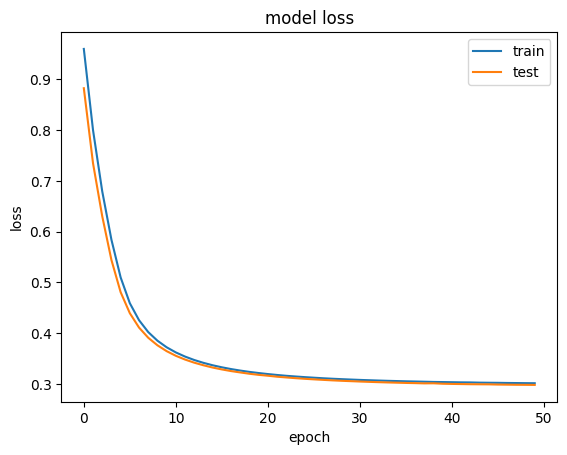

In [131]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()